This notebook is used to download and coregister a set of SLCs (called a "stack") in order to put them on the same grid. This is time consuming but can be made more efficient by increasing the downlook window for the automatic formation of interferograms, correlation, and unwrapped interferograms step (rlooks and alooks variables in the stackConfigs.py file), limiting the desired polarizations to just VV, or making the date range or polygon/bounding box smaller. 
<br>
<br>
Use the "earthscope_insar" conda environment as the Python kernel.
***

In [ ]:
# Import necessary packages.
import os, stat
import glob
import pandas
from pathlib import Path
from osgeo import gdal
# import datetime 
# from dateutil import parser
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import stackConfigs as sC
import re, isce, isceobj 
from isceobj.Util.ImageUtil import ImageLib as IML
# import subprocess

In [ ]:
# NOTE
# os.system(command) seems to be deprecated, so instead I recommend using subprocess.run()
# to use it, you have to uncomment the line above to "import subprocess" 

### Go to Vertex and do an initial search:
Vertex: https://search.asf.alaska.edu/#/?dataset=SENTINEL-1 <br>
You should narrow down your area of interest, and which track you are using. Choose a bounding box (draw on map) - all frames that even touch it will be downloaded, so take some care in choosing a reasonable bounds. <br>
Copy the "Area of Interest WKT" format lat/lon bounds from Vertex, and paste them into the stackConfigs.py file. <br>
Set other relevant information in stackConfigs.py (start and end dates, track, working directories, path to where the DEM is/will be, etc.)


In [2]:
# Which polarizations do you want to download? 
pols=('VV','VH') # VH is optional, not used in this study.
print(sC.pltdate) # this will be the interferogram that gets plotted to make sure the code worked and to select a crop region.
print(sC.workdir) # this is where all downloaded files will go 

#make raw and orbits directories if they don't already exist.
Path(sC.workdir + '/raw').mkdir(parents=True, exist_ok=True)
Path(sC.workdir + '/orbits').mkdir(parents=True, exist_ok=True)
for pol in pols:
    Path(sC.workdir + '/'+pol).mkdir(parents=True, exist_ok=True)

20180610_20180622
/mnt/data/SuperstitionHills/Data_and_Figs


### Download a DEM
It is best to do this yourself and put it in a directory called DEM in your workdir.  <br>
I use the GMTSAR DEM download tool for small areas (if only using 1 or a few 1 degree by 1 degree grid cells): https://topex.ucsd.edu/gmtsar/demgen/ <br>
You can stitch multiple grid cells of a DEM together with gdal: https://gdal.org/en/stable/programs/gdal_merge.html 
Another method is to use dem.py on command line, instructions here: https://github.com/isce-framework/isce2/blob/main/applications/dem.py <br>
If dem.py fails, try adding -u http://step.esa.int/auxdata/dem/SRTMGL1 to the end of your call.  Then run fixImageXml.py on the DEM.

### Construct a list of SLCs to download

In [ ]:
# Construct a list of files to download

# Put together an API (application programming interface) string to run to do this.
apistring='https://api.daac.asf.alaska.edu/services/search/param?platform=S1&beamSwath=IW&processingLevel=SLC'+sC.track+sC.date1+sC.date2+sC.polygon
os.system('wget \"'+apistring+'&output=csv\" -O '+sC.workdir+'/list.csv -q')
# this gives api that can be searched as url for list of files using different output types
print(apistring)
# to search this api, copy the apistring as a URL in an internet browser and add "&output=count" to see the count of how many files you will download.

### See which files still need to be downloaded

In [3]:
# some of this may already be done if this is not your first batch of downloads for this stack. 
# so, sort the list of SLC dates that need to be downloaded and see what has already been done. 
# this will print out how many dates have yet to be downloaded/coregistered and how many batches that will take.

df            = pandas.read_csv(sC.workdir+'/list.csv')
df['date']    = pandas.to_datetime(pandas.Series(df.loc[:,['Acquisition Date']].squeeze().str[0:10].values))
df            = df.sort_values('date',ignore_index=True)
numfiles      = np.shape(df)[0]

uniqueDates   = df['date'].dt.date.unique()
uniqueDates.sort()

totNumDates   = np.size(uniqueDates)
uniqueDateStr = [d.strftime('%Y%m%d') for d in uniqueDates]
refDateStr    = uniqueDateStr[0]
print(str(totNumDates)+ ' unique dates and ' + str(numfiles) +' total files')

coregSLCDir = os.path.join(sC.workdir,'VV/coreg_secondarys') 
if os.path.exists(coregSLCDir):
    coregSecondarys = glob.glob(os.path.join(coregSLCDir, '[0-9]???[0-9]?[0-9]?'))
    coregSLC        = [os.path.basename(slc) for slc in coregSecondarys]
    coregSLC.append(refDateStr)
    coregSLC.sort()

    if len(coregSLC)>0:
        print('It looks like the following '+str(len(coregSLC))+' dates have already been done')
        print(coregSLC)
        remNumDates = totNumDates-len(coregSLC)
        
    else:
        print('coreg dates empty, should probably check?')
        remNumDates = totNumDates

else:
    coregSLC = []
    remNumDates = totNumDates


newDates = np.setdiff1d(uniqueDateStr,coregSLC)
batches  = int(np.ceil(remNumDates / sC.targetNumDates))

print(str(remNumDates)+' dates still to process, length of newDates='+str(newDates.size))
print(newDates)
print(str(batches)+' batches based on '+str(sC.targetNumDates)+ ' dates/batch')
if len(newDates)>0:
    print('Next date would be '+str(newDates[0]))

271 unique dates and 448 total files
It looks like the following 241 dates have already been done
['20180610', '20180622', '20180704', '20180716', '20180728', '20180809', '20180821', '20180902', '20180914', '20180926', '20181008', '20181020', '20181101', '20181113', '20181125', '20181207', '20181219', '20181231', '20190112', '20190124', '20190205', '20190217', '20190301', '20190313', '20190325', '20190406', '20190430', '20190512', '20190524', '20190605', '20190617', '20190629', '20190711', '20190723', '20190804', '20190816', '20190822', '20190828', '20190903', '20190909', '20190915', '20190921', '20190927', '20191003', '20191009', '20191015', '20191021', '20191027', '20191102', '20191108', '20191114', '20191120', '20191126', '20191202', '20191208', '20191214', '20191220', '20191226', '20200101', '20200107', '20200113', '20200119', '20200125', '20200131', '20200206', '20200212', '20200218', '20200224', '20200301', '20200307', '20200313', '20200319', '20200325', '20200331', '20200406', '

### Figure out which SLCs will be downloaded for the current batch

In [ ]:
# The first batch of SLC downloads/coregistering should contain the reference date, in this case the first (earliest) date in the set.
# begin your first batch 

i=3 #batch number, used in stackLoop later on.
if len(coregSLC)>0:
    index=len(coregSLC)
else:
    index=0
print('Downloading data for batch '+str(int(i)))

# figure out and print out some information about this run (e.g., which dates still need to be downloaded, etc.)
dateindices=index+np.arange(sC.targetNumDates)
dateindices=dateindices[dateindices<=totNumDates-1]
print('Indices of the SLCs that still need to be downloaded:')
print(dateindices)
print('SLC dates that still need to be downloaded:')
for k in dateindices:
    print(uniqueDateStr[k])
deleteDates=uniqueDateStr[1:dateindices.max()-sC.noverlap*2]
print('SLC dates that, after this run, will have their raw files deleted to save space (do not need them after this run):')
print(str(deleteDates))

### Download the SLCs for this batch

In [ ]:
# using the list of SLC files we need, download them here. This takes a long-ish time to run. 
# you need to have a .netrc file set up with a valid username and password for an EarthData account to access these files from ASF
for k in dateindices:
    indices=np.argwhere(df['date'].dt.date==uniqueDates[k]).flatten()
    print(str(len(indices))+' files for date '+uniqueDateStr[k])
    for l in indices:
        rawFile=df['URL'][l]
        rawRoot=os.path.basename(rawFile)   
        if os.path.exists(os.path.join(sC.workdir,'raw',rawRoot)):
            print(rawRoot+' already downloaded')
        else:
            print('Downloading '+rawRoot)
            #this works if .netrc is set up correctly!!!
            wstr='wget '+ rawFile + ' --directory-prefix=' + sC.workdir + '/raw'
            os.system(wstr+'  --show-progress  --progress=bar:force:noscroll')    
    index+=1
print('\n\nDone.')

# NOTE
# If it logged out/failed partway through downloading an SLC, you need to check its size to make sure it is about the same as the others. 
# Each SLC is ~4 GB so if it's smaller than that, it probably didn't finish downloading.
# If the file is much smaller than the others, delete it and re-download it before continuing.

### Download the corresponding orbit files

In [ ]:
# Download the orbit files

command ='eof --search-path '+sC.workdir+'/raw --save-dir '+sC.workdir+'/orbits/'
os.system(command)
# There are sometimes issues with this because it changes frequently. 
# Check online to see how other people have troubleshot your issue if you run into one.

### Create the run files for each processing step for this batch

In [ ]:
# Preps the info for coregistering your stack of SLCs. 
# This will print out a bunch of info, check to make sure everything looks correct. 
# This should make a bunch of run files that will need to be executed in order 
#   (which we will make another file that will march down the run files to execute each in the proper order)

# NOTE
# this only works if you do not already have a bunch of run_files or a runstuff file that already exist. 
# It needs to start fresh for this batch you are currently running. 

# ANOTHER NOTE
# if this is NOT your first time running this (not your first batch), runstuff and run_files need to have been deleted 
# *before* this step (stackSentinel.py) so that it starts fresh.

for pol in pols:
    command='stackSentinel.py -s '+sC.workdir+'/raw -V False -o '+sC.workdir+'/orbits -a '+sC.workdir+'/aux/ -w '+sC.workdir+'/'+pol+' -d '+sC.dem+sC.narrowpoly+sC.swaths+sC.looks+sC.connects+sC.nESD+' -W interferogram -p '+pol.lower()
    print(command)
    os.system(command)

### Eliminate redundancies if creating a VH SLC stack in addition to VV

In [ ]:
# If you are creating a stack of both polarizations (VV and VH), some run files don't need to be executed for both polarizations 
# because it will be duplicating the effort for the same results. 

# This cell only needs to be run if your pol variable contains 'VH' in addition to VV. 

os.system('rm '+sC.workdir+'/VH/run_files/*average_baseline*')
os.system('rm '+sC.workdir+'/VH/run_files/*pairs_misreg*')
os.system('rm '+sC.workdir+'/VH/run_files/*timeseries_misreg*')
os.system('rm '+sC.workdir+'/VH/run_files/*extract_stack_valid_region*')

# We also can link directories from VV that we don't need to replicate for VH because it would be the same information in both.

os.system('ln -s '+sC.workdir+'/VV/misreg '+sC.workdir+'/VH/')
os.system('ln -s '+sC.workdir+'/VV/geom_reference '+sC.workdir+'/VH/')
os.system('ln -s '+sC.workdir+'/VV/stack '+sC.workdir+'/VH/')

### Put all the necessary stacking/coregistering subroutines into a single "parent" script 

In [ ]:
# Compile all the commands to run the runfiles in order into a single file for each polarization. 
# This puts all the run file commands into one place so instead of executing each step individually, it will march 
# through all the steps automatically, by running this one "parent" script.

# This script also ensures that any warnings/errors are captured into files so that the user can find where things went wrong
# if there was an interruption in the run for some reason.

# NOTE
# this only works if you are starting fresh, i.e., without an existing "runstuff" script in the working directory 
# and the runstuff and run_files need to have been deleted *before* running stackSentinel.py

for pol in pols:
    runfiles=os.listdir(sC.workdir+'/'+pol+'/run_files')
    runfiles.sort()

    runf = open(sC.workdir+'/runstuff'+pol,'w+')
    for file in runfiles:
        runf.write('if test -f "'+sC.workdir+'/'+pol+'/run_files/'+file+'.out"; then\n')
        runf.write('     echo "'+file+' done"\n')
        runf.write('else\n')
        runf.write('      '+sC.workdir+'/'+pol+'/run_files/'+file+' > '+sC.workdir+'/'+pol+'/run_files/'+file+'.out 2> '+sC.workdir+'/'+pol+'/run_files/'+file+'.errout\n')
        runf.write('fi\n')
        os.chmod(sC.workdir+'/'+pol+'/run_files/'+file,stat.S_IRWXU) #make executable

    runf.close()
    os.chmod(sC.workdir+'/runstuff'+pol,stat.S_IRWXU)

### Eliminate redundant steps for VH in configuration files

In [ ]:
# Again, we do not want to duplicate redundant steps for VH if they will be the same as for VV. 
# So, we need to fix the runstuff script and some run_files commands so that we do not repeat steps unecessarily and waste time.

# NOTE
# This only applies if the user includes the VH polarization in the data download/coregistration.

fname=sC.workdir+'/VH/configs/config_reference'
os.system('cp '+fname+' '+fname+'.old')

f1=open(fname)
lines=f1.readlines()
f1.close()

#get indices of lines that match "topo"
resul=[re.search('topo',l) for l in lines]
testi=[i for i,v in enumerate(resul) if v]

if(len(testi)>0):
#only write up to right before the first "topo".
    f1=open(fname,'w')
    [f1.write(line) for line in lines[0:testi[0]-1]]
    f1.close()

### Create a script for deleting unecessary files for *AFTER* downloading/coregistering this batch of SLCs

In [ ]:
# Make a file that includes commands for deleting specific files that we no longer need after 
# successfully cropping all the coregistered SLCs that we produced in this batch.

# NOTE
# This does not actually delete anything yet! It just sets it up so that we can delete the proper files AFTER the batch run.

runf = open(sC.workdir+'/deleteStuff','w+')

for date in deleteDates:
    runf.write('rm '+sC.workdir+'/raw/*'+date+'*\n')  #star means in all subfiles find all run files
    # after the first run, make sure it only deletes the proper file(s). 
    # (always keeps the very first date, and then three at the end to make 'connect3' igrams for next batch.)

for date in deleteDates:
    for pol in pols:
        runf.write('rm -f '+sC.workdir+'/'+pol+'/coreg_secondarys/'+date+'/*/*off\n')
        runf.write('rm -f '+sC.workdir+'/'+pol+'/coreg_secondarys/'+date+'/*/*slc\n')          
   
runf.write('rm -rf '+sC.workdir+'/VV/ESD\n')
runf.write('rm -rf '+sC.workdir+'/VV/coarse_interferograms\n')

for pol in pols:
    runf.write('rm -rf '+sC.workdir+'/'+pol+'/interferograms\n')
    runf.write('rm -rf '+sC.workdir+'/'+pol+'/merged/SLC_*\n')
    runf.write('rm -rf '+sC.workdir+'/'+pol+'/run_files\n')
runf.close()

os.chmod(sC.workdir+'/deleteStuff',stat.S_IRWXU)

### Run the parent scripts to execute the subroutines to carry out the coregistration steps 

In [ ]:
# This is the most time consuming step: running the subroutines in run_file/ using the runstuffVX scripts. 
# Check the directory run_files for the log and error files, they will populate as it runs. 

# NOTE
# You can do this step on a command line if you want to start a screen session, for example, so you can step 
# away from your computer without anything being interrupted. 
#   E.g., if you code in VScode and you a remote logged into a computer and you know you will be logged out at some point 
#   or want to shut your laptop, which forces a log out. 

os.system(sC.workdir+'/runstuffVV')
os.system(sC.workdir+'/runstuffVH')

### Check output and select crop area bounds

[[20000  2475  9000  1575]]
<osgeo.gdal.Dataset; proxy of <Swig Object of type 'GDALDatasetShadow *' at 0x7eae02a98b40> >


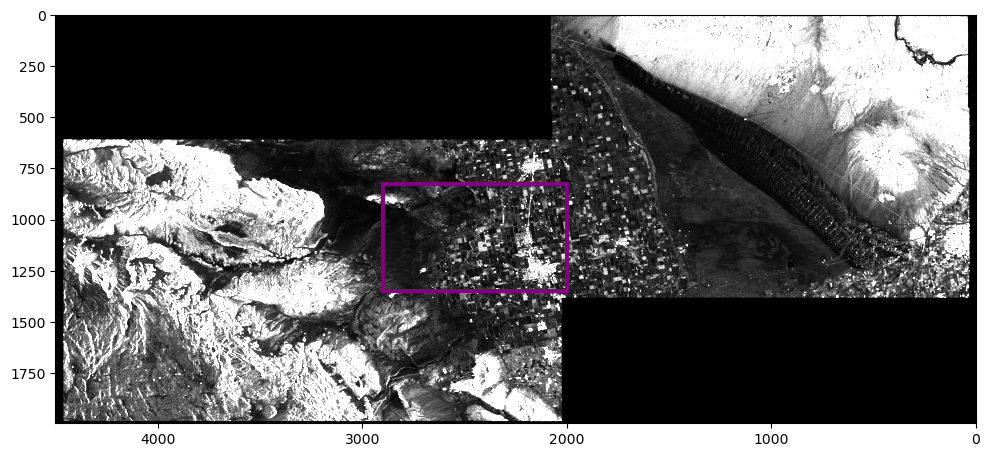

In [ ]:
# Checking to see if everything ran properly (before deleting anything!)
# Is there a merged directory with files/folders inside? There should be. 

# Now we can select our crop location(s). 

print(sC.croppoly)

ds = gdal.Open(sC.workdir+"/VV/merged/interferograms/"+sC.pltdate+"/fine.int", gdal.GA_ReadOnly)
print(ds)
data_array = ds.GetRasterBand(1).ReadAsArray()

ang_data_array= np.angle(data_array)
abs_data_array= np.abs(data_array)

plt.figure(figsize=(10, 12),tight_layout=True)
#plt.imshow(ang_data_array,vmin=-np.pi, vmax=np.pi, cmap='jet',interpolation='nearest')
plt.imshow(abs_data_array,vmin=0, vmax=10000, cmap='gray')

#now loop over polygons
for i in np.arange(sC.croppoly.shape[0]):
    #bounds of our cropped region
    x1=int(sC.croppoly[i,0]/sC.rlooks)
    x2=x1+int((sC.croppoly[i,2])/sC.rlooks)
    y1=int(sC.croppoly[i,1]/sC.alooks)
    y2=y1+int((sC.croppoly[i,3])/sC.alooks)
    
    rect=mpatches.Rectangle((x1,y1),(x2-x1),(y2-y1), 
                        fill=False,
                        color="purple",
                       linewidth=3)
                       #facecolor="red")
    plt.gca().add_patch(rect)
plt.gca().invert_xaxis()
plt.show()

# if you are not pleased with the current cropping bounding box(es), change the values in the stackConfigs.py file, 
# save it, then re-run the "import necessary packages" code cell, an come down to this code cell and re-run it. 
# Once you are happy with your bounding box, you can move to the next step. 

# NOTE
# You can have more than one bounding box for cropping if you desire. 
# Add another series of coordinates to the cropPoly variable in the stackConfigs.py file, like so: 
#   croppoly = np.array([[xstart1,ystart1,dx1,dy1],[xstart2,ystart2,dx2,dy2]])
# I think these can overlap if you want, but I have not tested that. 

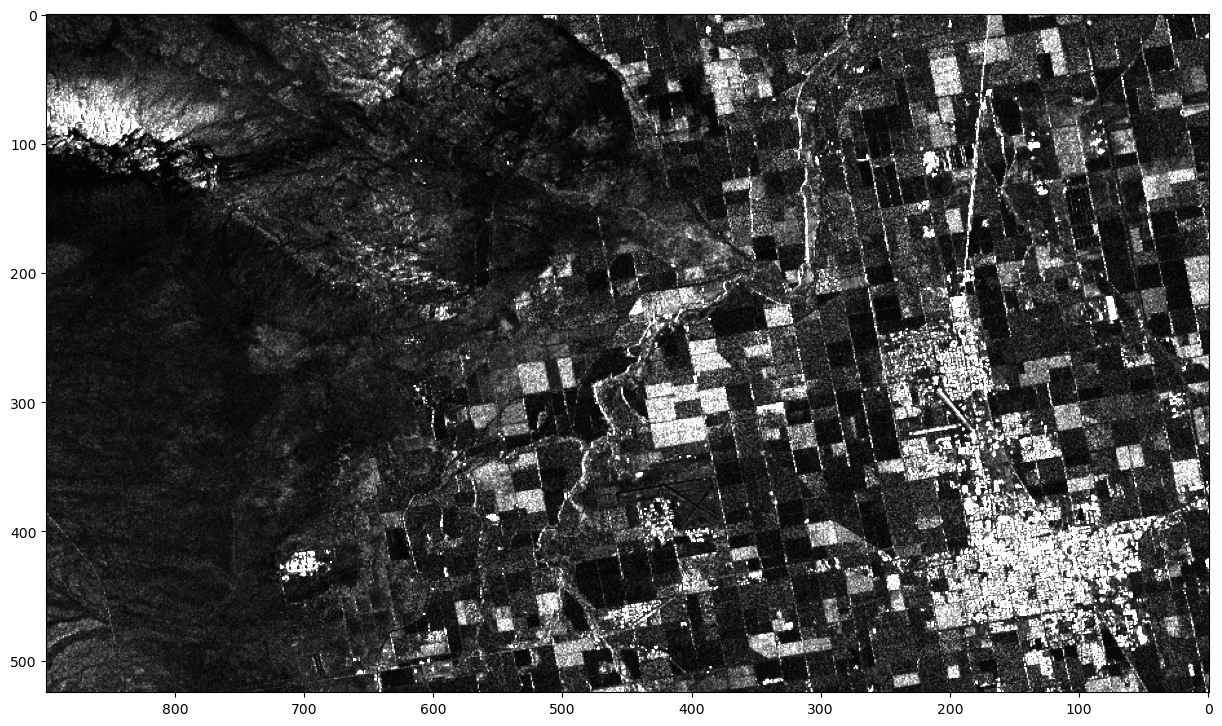

In [ ]:
# Plot only the area that will be cropped to in order to double check: 

for i in np.arange(sC.croppoly.shape[0]): #loop over polygons again
    #bounds of our cropped region
    x1=int(sC.croppoly[i,0]/sC.rlooks)
    x2=int((sC.croppoly[i,0]+sC.croppoly[i,2])/sC.rlooks)
    y1=int(sC.croppoly[i,1]/sC.alooks)
    y2=int((sC.croppoly[i,1]+sC.croppoly[i,3])/sC.alooks)

    plt.figure(figsize=(15, 16))
    #plt.imshow(ang_data_array[y1:y2,x1:x2],vmin=-np.pi, vmax=np.pi, cmap='jet',interpolation='nearest')
    plt.imshow(abs_data_array[y1:y2,x1:x2],vmin=0, vmax=10000, cmap='gray')
    plt.gca().invert_xaxis()
plt.show()

In [ ]:
# Fix paths to add vrt to any image that doesn't have it.
# This will make loading/plotting the images feasible. 
for pol in pols:
    for path, dirs, files in os.walk(os.path.join(sC.workdir,pol,'merged')):
        for fname in (files + dirs):
            if fname[-4:] == '.xml':
                if fname[-7:] != 'aux.xml':
                    fname= os.path.join(path, fname)
                    fname = os.path.splitext(fname)[0]
                    fdir = os.path.dirname(fname)
                    fname = os.path.abspath(os.path.join(fdir, os.path.basename(fname)))
                    img = IML.loadImage(fname)[0]
                    img.filename = fname
                    img.setAccessMode('READ')
                    img.renderHdr()

### Crop the SLCs

In [ ]:
# Now we need to crop the coregistered stack of SLCs to the desired bounds.
# Only do this if you are certain that all prior processing steps were successful, and that you have 
# your desired cropPoly bounds exactly correct in your stackConfigs file \ 

os.system('cropAll.py') 

# NOTE
# This can be run in the terminal instead (might take a while).

### Delete unecessary files to clear up space

In [ ]:
# Now we can run the delete stuff script so that for the next batch, we have freed up more space
# on the computer and gotten rid of unecessary intermediate files. 

os.system(sC.workdir+'/deleteStuff')
# This can also be run on the terminal instead. 

In [ ]:
# You will end up with a file structure like so: 

# All contained in the working directory that is defined in the stackConfigs.py file 

# subfolders are:
#   orbits, raw, VV, VH (if included), maybe DEM if that is where you put the DEM manually, 
#   AND the "cropped_x1_y1_dx_dy" folder (there will be one for each crop polygon that you defined in the stackConfigs.py file)

# in VV (or VH), there will be folders: configs, coreg_secondarys, merged, orbits, reference, secondarys, etc. 
#   The files in these folders will exist *during* the stacking/coregistering run, but some will get deleted after each batch 
#       during the "deleteStuff" run. 

# in the cropped_x1_y1_dx_dy folder: 
#   there will be folders: VV and VH (if included)
#   in each of those, there will be folders: interferograms, SLC, and geom_reference (only in the VV folder)

#       The interferograms folder has a few files for each date pair that has been made, the number of which 
#       depends on the nconnect in the stackConfigs.py file. These interferograms are downlooked by alooks x rlooks.   
#           filt_fine.cor = multilooked correlation 
#           filt_fine.int = multilooked interferogram             
#           filt_fine.unw = multilooked unwrapped interferogram 
#           fine.cor =      full resolution(?) correlation
#           fine.int =      full resolution(?) interferogram 
#       * Note that some/all of these files have multiple raster bands 
#           so be careful that you are loading the data you intend to use
   
#       The SLC folder will have folders named by the SLC date, with the full resolution, cropped SLC inside. 
#           named 'YYYYMMDD.slc.full' 
#           This is what I use in my analysis. 

#       The geom_reference folder will have the DEM in radar coordinates (hgt.rdr.full), the latitudes of each full resolution pixel 
#           in radar coordinates (lat.rdr.full), the longitudes (lon.rdr.full), and the line-of-sight incidence angle? (los.rdr.full).